<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/24_gru_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GRU 기반 테슬라 주가 예측

**학습목표:** GRU의 기본 구조, 10거래일 Sliding Window, 하이퍼파라미터 튜닝을 순차적으로 학습하고, 시간순 외표본에서 Naïve 기준모형과 비교합니다.

- 모든 그래프는 흰색 배경과 영어 레이블을 사용합니다.
- Train 60% / Validation 20% / Test 20%를 **시간순**으로 구분합니다.
- Scaler는 Train 구간에서만 학습하며, Validation은 Early Stopping/모델 선택, Test는 최종 평가에만 사용합니다.
- 1단계는 날짜 하나만 입력하는 GRU의 한계 사례입니다. 2~3단계는 과거 10거래일 종가를 사용한 **다음 거래일 종가 예측**입니다.
- 주가 데이터는 교육용 시계열 예측에 사용되며 미래 성능이나 투자수익을 보장하지 않습니다.

## 1. GRU 기초: 날짜 1개를 입력하는 한계 사례

**주의:** 입력 크기 `(samples, 1, 1)`은 시퀀스 길이가 1이므로 순차적 기억을 충분히 활용하지 못합니다. 이 실습은 모델 구조를 익히기 위한 비교 사례이며, 주가 예측에 적합한 구조임을 주장하지 않습니다.

**실습 흐름:** TSLA 다운로드 → 시간순 분할 → Train-only 정규화 → GRU 학습 → Test/Naïve 비교 → 결과 해석

          Model    MAE   RMSE     R2
GRU (Day index) 25.999 30.013 -1.967
          Naive  5.295  7.110  0.833


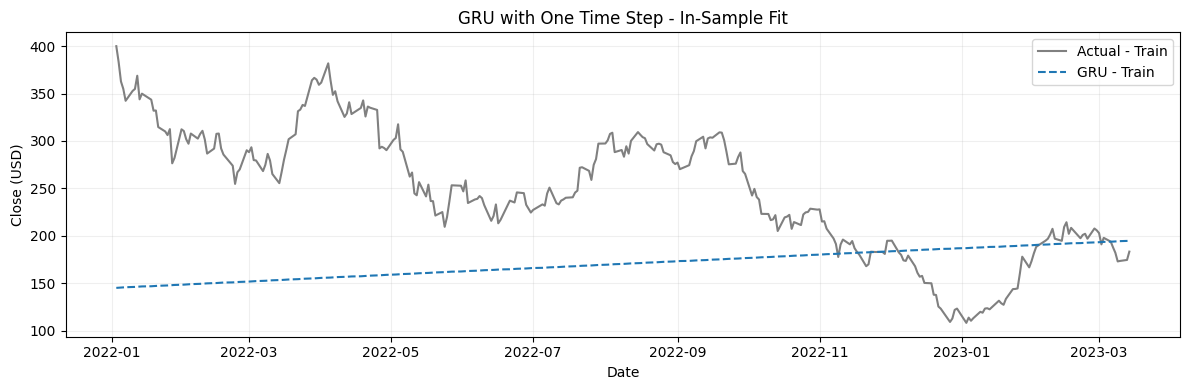

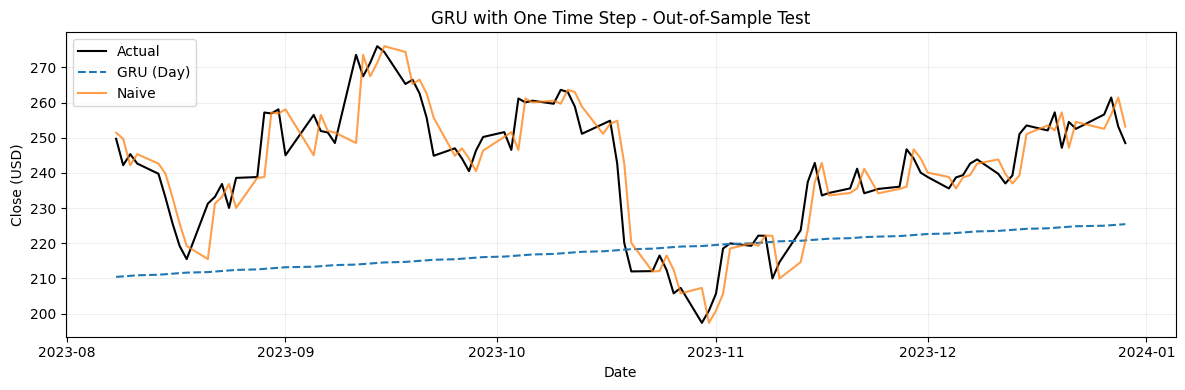

해석: 날짜 인덱스만으로 만든 GRU가 미래 주가를 잘 예측한다고 결론낼 수 없습니다.


In [1]:
# [실습 1] 날짜 인덱스만 사용한 GRU: 시계열 기억의 한계를 보여주는 예제
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# TSLA 종가를 다운로드합니다. auto_adjust=True는 분할 등 가격 조정을 반영합니다.
# end는 제외되는 날짜이며, 다운로드 오류 또는 빈 데이터는 명시적으로 확인합니다.
df = yf.download('TSLA', start='2022-01-01', end='2024-01-01', auto_adjust=True, progress=False)
if df.empty:
    raise RuntimeError('TSLA 데이터를 다운로드하지 못했습니다. 네트워크 상태를 확인하세요.')
# yfinance 버전에 따라 MultiIndex인 Close 컬럼을 1차원 Series로 변환합니다.
close = df['Close']
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]
close = close.astype(float).dropna().rename('Close')
if len(close) < 100:
    raise ValueError('학습/검증/테스트 분리에 필요한 관측치가 부족합니다.')

# 날짜 자체를 설명변수로 사용합니다. 이는 과거 종가를 입력하는 예측과 다릅니다.
X = np.arange(len(close), dtype=float).reshape(-1, 1)
y = close.to_numpy().reshape(-1, 1)
n = len(y); train_end = int(n*0.6); val_end = int(n*0.8)
# 미래 구간의 정보(최대·최소)를 사용하지 않도록 Train에서만 scaler.fit() 수행.
scaler_X = MinMaxScaler().fit(X[:train_end]); scaler_y = MinMaxScaler().fit(y[:train_end])
Xs = scaler_X.transform(X).reshape(-1, 1, 1)
ys = scaler_y.transform(y)
X_train, y_train = Xs[:train_end], ys[:train_end]
X_val, y_val = Xs[train_end:val_end], ys[train_end:val_end]
X_test, y_test = Xs[val_end:], ys[val_end:]

# time_steps=1: GRU의 시간적 의존성을 사실상 활용하지 못하는 구조입니다.
model = Sequential([Input(shape=(1,1)), GRU(50, activation='tanh'), Dense(1)])
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=100, batch_size=16,
                    validation_data=(X_val, y_val), shuffle=False,
                    callbacks=[EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)],
                    verbose=0)
train_pred = scaler_y.inverse_transform(model.predict(X_train, verbose=0)).ravel()
test_pred = scaler_y.inverse_transform(model.predict(X_test, verbose=0)).ravel()
train_actual = y[:train_end, 0]; test_actual = y[val_end:,0]
test_dates = close.index[val_end:]
# 테스트 첫날의 Naïve 예측도 직전 관측일(검증구간 마지막날)의 실제 종가를 사용합니다.
naive_pred = y[val_end-1:-1,0]
assert len(test_actual) == len(test_pred) == len(naive_pred) == len(test_dates)

# MAE/RMSE/R2: R2는 비정상적인 주가 수준에서 낮거나 음수일 수도 있습니다.
def report_regression(name, actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    return {'Model':name, 'MAE':mae, 'RMSE':rmse, 'R2':r2_score(actual,pred)}
print(pd.DataFrame([report_regression('GRU (Day index)', test_actual, test_pred),
                    report_regression('Naive',test_actual, naive_pred)]).round(3).to_string(index=False))

plt.figure(figsize=(12,4))
plt.plot(close.index[:train_end],train_actual,label='Actual - Train',color='gray')
plt.plot(close.index[:train_end],train_pred,label='GRU - Train',linestyle='--')
plt.title('GRU with One Time Step - In-Sample Fit');plt.xlabel('Date');plt.ylabel('Close (USD)')
plt.legend();plt.grid(alpha=.2);plt.tight_layout();plt.show()
plt.figure(figsize=(12,4))
plt.plot(test_dates,test_actual,label='Actual',color='black')
plt.plot(test_dates,test_pred,label='GRU (Day)',linestyle='--')
plt.plot(test_dates,naive_pred,label='Naive',alpha=.75)
plt.title('GRU with One Time Step - Out-of-Sample Test');plt.xlabel('Date');plt.ylabel('Close (USD)')
plt.legend();plt.grid(alpha=.2);plt.tight_layout();plt.show()
print('해석: 날짜 인덱스만으로 만든 GRU가 미래 주가를 잘 예측한다고 결론낼 수 없습니다.')

## 2. Sliding Window GRU: 과거 10거래일로 다음 거래일 예측

**입력:** 과거 10일 종가 / **목표:** 그 다음 거래일의 종가.

$$
\hat{Y}_{t|t-1}=f(Y_{t-10},Y_{t-9},\ldots,Y_{t-1})
$$

- 윈도우 생성 시 목표일 당일 종가를 입력에 포함하지 않습니다.
- 분할은 **정답 날짜**를 기준으로 합니다. 검증/테스트 윈도우에 그보다 앞선 시점의 종가가 들어가는 것은 실제 예측에서도 이용 가능한 과거 정보입니다.
- Train 기준의 MinMaxScaler를 적용하고, Test를 Early Stopping에 사용하지 않습니다.

              Model   MAE   RMSE    R2
GRU (10-day window) 8.892 11.215 0.586
              Naive 5.295  7.110 0.833


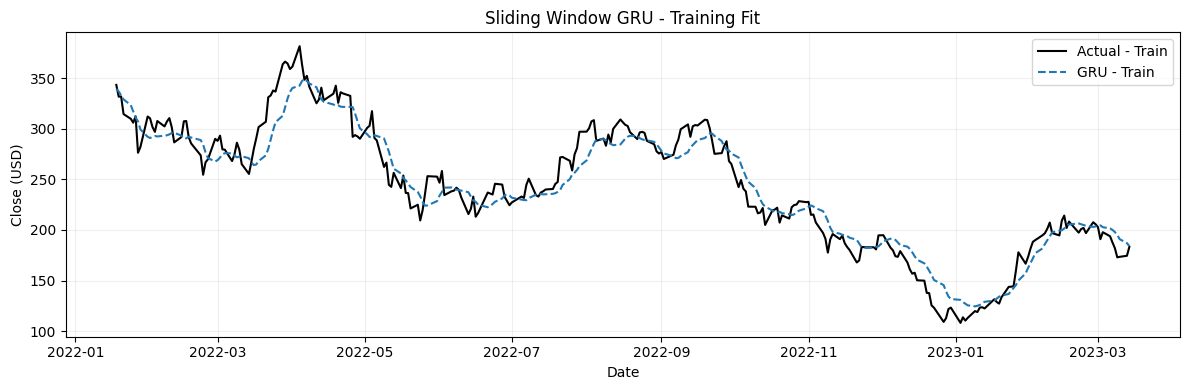

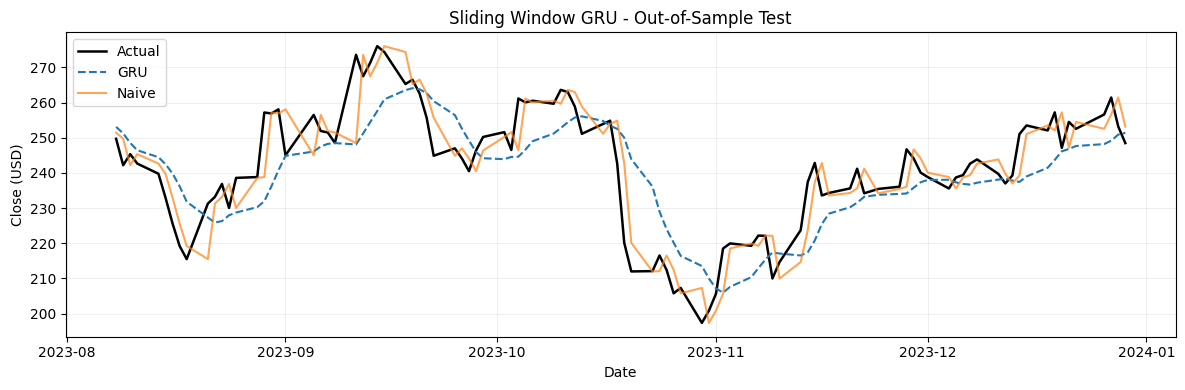

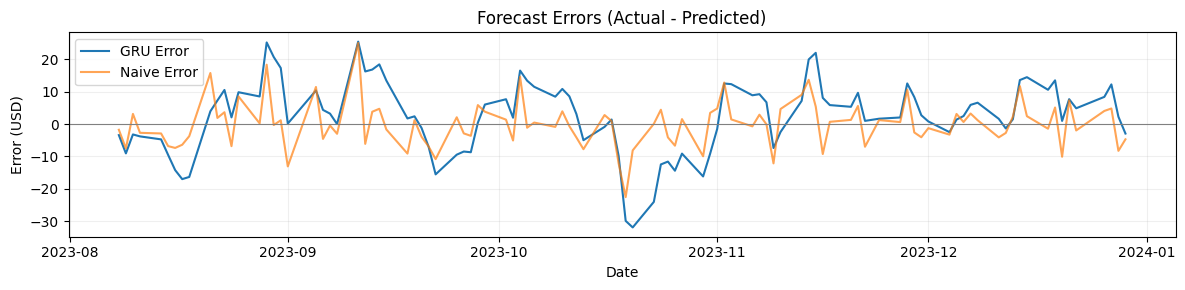

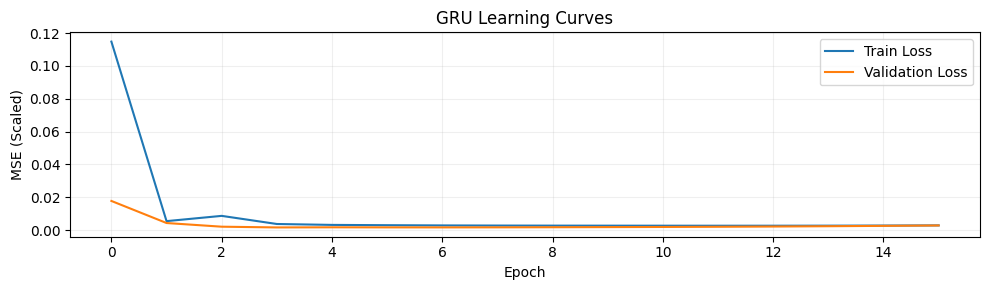

해석: 모델별 MAE/RMSE를 비교하세요. 주가 예측선이 겹쳐도 오차 그래프는 차이를 보여줍니다.


In [2]:
# [실습 2] 실제 Sliding Window GRU (다음 거래일 종가 예측)
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42); tf.random.set_seed(42)
plt.rcParams['figure.facecolor']='white';plt.rcParams['axes.facecolor']='white'
df = yf.download('TSLA',start='2022-01-01',end='2024-01-01',auto_adjust=True,progress=False)
if df.empty: raise RuntimeError('TSLA 다운로드 실패')
close = df['Close']
if isinstance(close,pd.DataFrame):close=close.iloc[:,0]
close = close.astype(float).dropna()
prices = close.to_numpy().reshape(-1,1)
window_size=10
if len(prices)<window_size+80:raise ValueError('관측치가 부족합니다.')
# 정답의 원시 시점으로 Train/Validation/Test를 분할합니다.
n=len(prices); train_end=int(n*.6); val_end=int(n*.8)
scaler=MinMaxScaler().fit(prices[:train_end]) # 미래값으로 fit하지 않습니다.
scaled=scaler.transform(prices)

def create_sliding_window_data(data, window_size):
    # target_indices[j]는 X[j]가 예측하는 날짜의 위치입니다.
    X,y,idx=[],[],[]
    for t in range(window_size,len(data)):
        X.append(data[t-window_size:t]);y.append(data[t]);idx.append(t)
    return np.asarray(X),np.asarray(y),np.asarray(idx)

X,y,target_idx=create_sliding_window_data(scaled,window_size)
train_mask=target_idx<train_end
val_mask=(target_idx>=train_end)&(target_idx<val_end)
test_mask=target_idx>=val_end
X_train,y_train=X[train_mask],y[train_mask]
X_val,y_val=X[val_mask],y[val_mask]
X_test,y_test=X[test_mask],y[test_mask]
assert X_train.shape[1:] == (window_size,1)

model=Sequential([Input(shape=(window_size,1)),
                  GRU(50,activation='tanh',return_sequences=True),
                  GRU(50,activation='tanh'),Dense(1)])
model.compile(optimizer='adam',loss='mse')
history=model.fit(X_train,y_train,epochs=100,batch_size=16,
                  validation_data=(X_val,y_val),shuffle=False,verbose=0,
                  callbacks=[EarlyStopping(monitor='val_loss',patience=12,restore_best_weights=True)])
train_pred=scaler.inverse_transform(model.predict(X_train,verbose=0)).ravel()
test_pred=scaler.inverse_transform(model.predict(X_test,verbose=0)).ravel()
train_actual=prices[target_idx[train_mask],0]
test_actual=prices[target_idx[test_mask],0]
naive_pred=prices[target_idx[test_mask]-1,0] # 실제 시점 t-1의 종가
train_dates=close.index[target_idx[train_mask]]
test_dates=close.index[target_idx[test_mask]]
assert len(test_dates)==len(test_pred)==len(test_actual)==len(naive_pred)

def evaluate(name, actual, forecast):
    return {'Model':name,'MAE':mean_absolute_error(actual,forecast),
            'RMSE':np.sqrt(mean_squared_error(actual,forecast)),
            'R2':r2_score(actual,forecast)}
print(pd.DataFrame([evaluate('GRU (10-day window)',test_actual,test_pred),
                    evaluate('Naive',test_actual,naive_pred)]).round(3).to_string(index=False))

plt.figure(figsize=(12,4))
plt.plot(train_dates,train_actual,label='Actual - Train',color='black')
plt.plot(train_dates,train_pred,label='GRU - Train',linestyle='--')
plt.title('Sliding Window GRU - Training Fit');plt.xlabel('Date');plt.ylabel('Close (USD)')
plt.grid(alpha=.2);plt.legend();plt.tight_layout();plt.show()
plt.figure(figsize=(12,4))
plt.plot(test_dates,test_actual,label='Actual',color='black',linewidth=1.8)
plt.plot(test_dates,test_pred,label='GRU',linestyle='--')
plt.plot(test_dates,naive_pred,label='Naive',alpha=.7)
plt.title('Sliding Window GRU - Out-of-Sample Test');plt.xlabel('Date');plt.ylabel('Close (USD)')
plt.grid(alpha=.2);plt.legend();plt.tight_layout();plt.show()
plt.figure(figsize=(12,3))
plt.plot(test_dates,test_actual-test_pred,label='GRU Error')
plt.plot(test_dates,test_actual-naive_pred,label='Naive Error',alpha=.7)
plt.axhline(0,color='gray',linewidth=.8)
plt.title('Forecast Errors (Actual - Predicted)');plt.xlabel('Date');plt.ylabel('Error (USD)')
plt.grid(alpha=.2);plt.legend();plt.tight_layout();plt.show()
plt.figure(figsize=(10,3))
plt.plot(history.history['loss'],label='Train Loss');plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('GRU Learning Curves');plt.xlabel('Epoch');plt.ylabel('MSE (Scaled)')
plt.grid(alpha=.2);plt.legend();plt.tight_layout();plt.show()
print('해석: 모델별 MAE/RMSE를 비교하세요. 주가 예측선이 겹쳐도 오차 그래프는 차이를 보여줍니다.')

## 3. KerasTuner를 이용한 GRU 하이퍼파라미터 선택

앞 실습과 같은 과거 10거래일 입력을 사용합니다. **Train(60%)으로 학습, Validation(20%)으로 설정 선택, Test(20%)로 마지막 한 번 평가**합니다.

KerasTuner의 `val_loss`는 Validation에서만 측정하며, 테스트 성능으로 GRU 유닛 수·활성화 함수·학습률을 고르지 않습니다. 학습과 검증 손실의 차이가 커진다면 과적합 여부를 의심할 수 있습니다.

In [3]:
!pip -q install -U keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.7 MB/s eta 0:00:00


Validation에서 선택된 GRU 설정: {'units': 16, 'activation': 'relu', 'learning_rate': 0.001}
    Model   MAE  RMSE    R2
Tuned GRU 5.867 7.752 0.802
    Naive 5.295 7.110 0.833


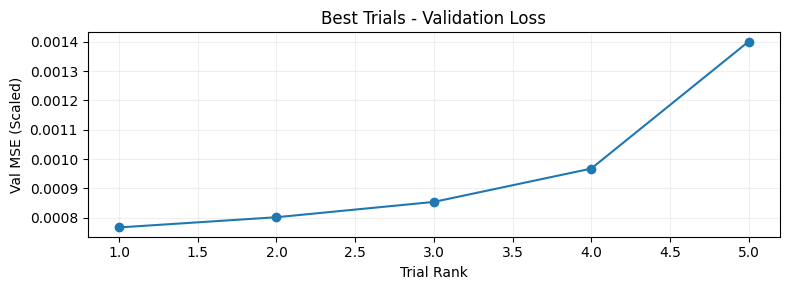

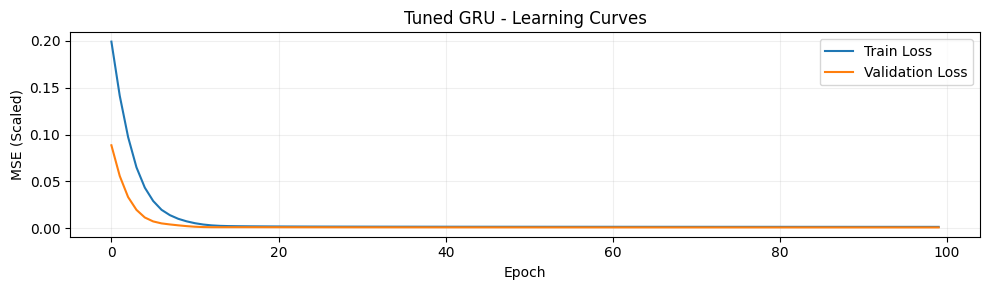

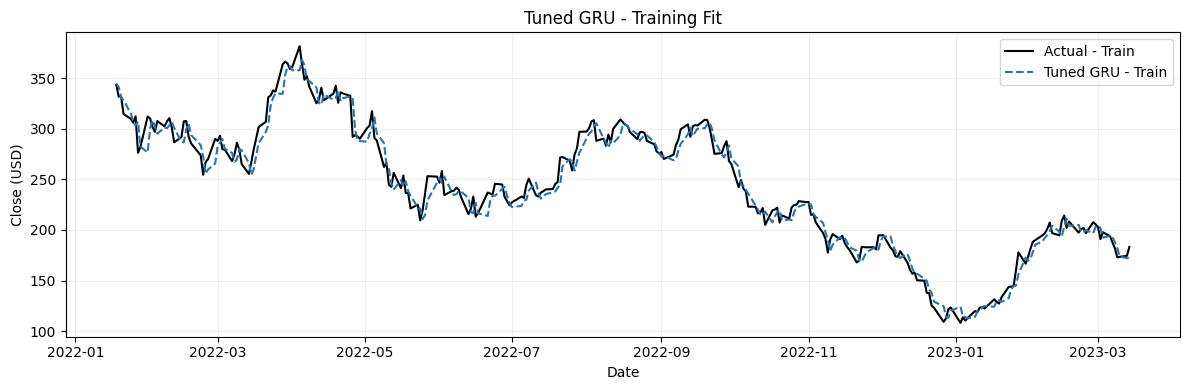

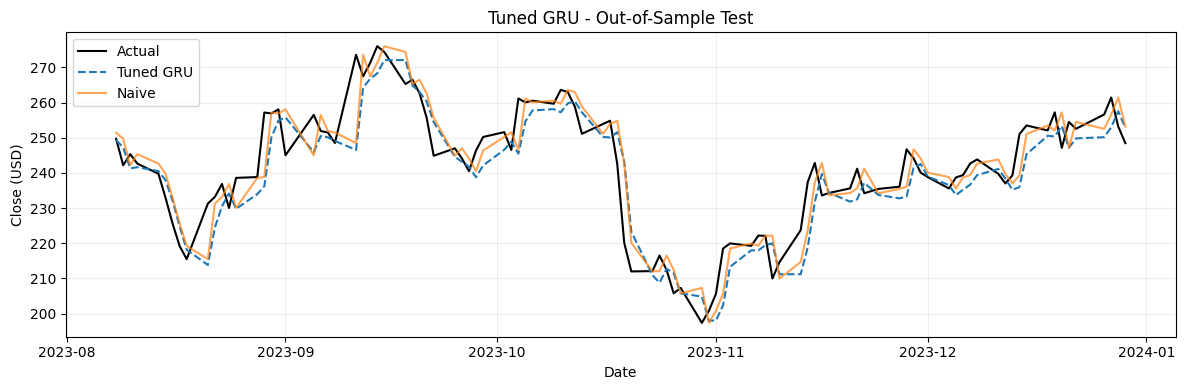

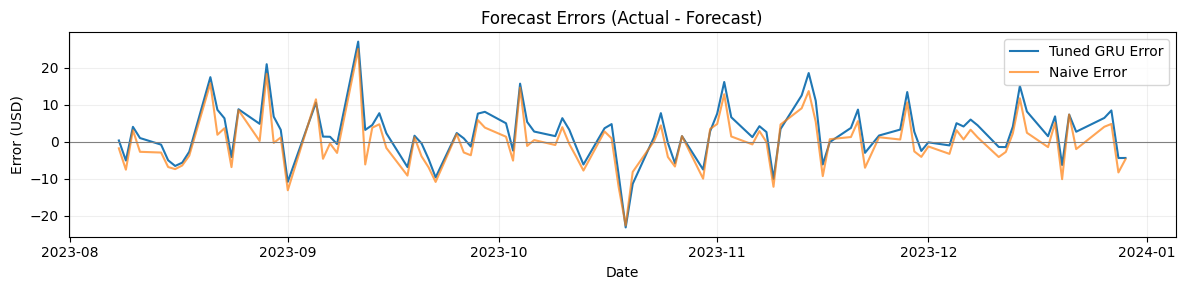

결과 해석: 검증 MSE가 작아도 테스트에서 Naive보다 우수하다는 보장은 없습니다.


In [4]:
# [실습 3] GRU 하이퍼파라미터 튜닝: Test를 탐색에 사용하지 않습니다.
import os
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import GRU,Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

np.random.seed(42); tf.random.set_seed(42)
plt.rcParams['figure.facecolor']='white';plt.rcParams['axes.facecolor']='white'
# 각 실습을 독립적으로 실행할 수 있도록 데이터를 다시 받습니다.
df=yf.download('TSLA',start='2022-01-01',end='2024-01-01',auto_adjust=True,progress=False)
if df.empty:raise RuntimeError('TSLA 다운로드 실패')
close=df['Close']
if isinstance(close,pd.DataFrame):close=close.iloc[:,0]
close=close.astype(float).dropna()
prices=close.to_numpy().reshape(-1,1)
window_size=10;n=len(prices)
if n<window_size+80:raise ValueError('관측치가 부족합니다.')
train_end=int(n*.6);val_end=int(n*.8)
scaler=MinMaxScaler().fit(prices[:train_end])
scaled=scaler.transform(prices)
# 각 윈도우의 목표일 t: 입력에 t 시점 종가는 절대 포함하지 않습니다.
X=np.array([scaled[t-window_size:t] for t in range(window_size,n)])
y=np.array([scaled[t] for t in range(window_size,n)])
target_idx=np.arange(window_size,n)
tr=target_idx<train_end
va=(target_idx>=train_end)&(target_idx<val_end)
te=target_idx>=val_end
X_train,y_train=X[tr],y[tr]
X_val,y_val=X[va],y[va]
X_test,y_test=X[te],y[te]

def build_model(hp):
    model=Sequential([Input(shape=(window_size,1)),
                      GRU(units=hp.Int('units',min_value=16,max_value=64,step=16),
                          activation=hp.Choice('activation',['tanh','relu'])),
                      Dense(1)])
    model.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate',[.001,.0005,.0001])),loss='mse')
    return model

# overwrite=True: 같은 디렉터리 내 기존 탐색 결과가 이번 탐색에 섞이지 않게 합니다.
tuner=kt.RandomSearch(build_model,objective='val_loss',max_trials=8,executions_per_trial=1,
                      directory='hyperparameter_tuning',project_name='Tesla_GRU_Tuning',
                      overwrite=True,seed=42)
tuner.search(X_train,y_train,epochs=50,batch_size=16,validation_data=(X_val,y_val),
             shuffle=False,verbose=0,
             callbacks=[EarlyStopping(monitor='val_loss',patience=8,restore_best_weights=True)])
best_hps=tuner.get_best_hyperparameters(1)[0]
print('Validation에서 선택된 GRU 설정:',best_hps.values)
best_model=tuner.hypermodel.build(best_hps)
history=best_model.fit(X_train,y_train,epochs=100,batch_size=16,
                       validation_data=(X_val,y_val),shuffle=False,verbose=0,
                       callbacks=[EarlyStopping(monitor='val_loss',patience=12,restore_best_weights=True)])
# Test는 최종 평가에만 사용합니다.
train_pred=scaler.inverse_transform(best_model.predict(X_train,verbose=0)).ravel()
test_pred=scaler.inverse_transform(best_model.predict(X_test,verbose=0)).ravel()
train_actual=prices[target_idx[tr],0]
test_actual=prices[target_idx[te],0]
naive_pred=prices[target_idx[te]-1,0]
train_dates=close.index[target_idx[tr]]
test_dates=close.index[target_idx[te]]
assert len(test_actual)==len(test_pred)==len(naive_pred)==len(test_dates)

def metrics_row(name,actual,pred):
    return {'Model':name,'MAE':mean_absolute_error(actual,pred),
            'RMSE':np.sqrt(mean_squared_error(actual,pred)),
            'R2':r2_score(actual,pred)}
print(pd.DataFrame([metrics_row('Tuned GRU',test_actual,test_pred),
                    metrics_row('Naive',test_actual,naive_pred)]).round(3).to_string(index=False))
# 하이퍼파라미터 후보별 Validation Loss: 낮을수록 검증구간 오차가 작습니다.
trials=tuner.oracle.get_best_trials(num_trials=5)
plt.figure(figsize=(8,3))
plt.plot(range(1,len(trials)+1),[z.metrics.get_best_value('val_loss') for z in trials],marker='o')
plt.title('Best Trials - Validation Loss');plt.xlabel('Trial Rank');plt.ylabel('Val MSE (Scaled)')
plt.grid(alpha=.2);plt.tight_layout();plt.show()
plt.figure(figsize=(10,3))
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Tuned GRU - Learning Curves');plt.xlabel('Epoch');plt.ylabel('MSE (Scaled)')
plt.grid(alpha=.2);plt.legend();plt.tight_layout();plt.show()
plt.figure(figsize=(12,4))
plt.plot(train_dates,train_actual,label='Actual - Train',color='black')
plt.plot(train_dates,train_pred,label='Tuned GRU - Train',linestyle='--')
plt.title('Tuned GRU - Training Fit');plt.xlabel('Date');plt.ylabel('Close (USD)')
plt.grid(alpha=.2);plt.legend();plt.tight_layout();plt.show()
plt.figure(figsize=(12,4))
plt.plot(test_dates,test_actual,label='Actual',color='black')
plt.plot(test_dates,test_pred,label='Tuned GRU',linestyle='--')
plt.plot(test_dates,naive_pred,label='Naive',alpha=.7)
plt.title('Tuned GRU - Out-of-Sample Test');plt.xlabel('Date');plt.ylabel('Close (USD)')
plt.grid(alpha=.2);plt.legend();plt.tight_layout();plt.show()
plt.figure(figsize=(12,3))
plt.plot(test_dates,test_actual-test_pred,label='Tuned GRU Error')
plt.plot(test_dates,test_actual-naive_pred,label='Naive Error',alpha=.7)
plt.axhline(0,color='gray',linewidth=.8)
plt.title('Forecast Errors (Actual - Forecast)');plt.xlabel('Date');plt.ylabel('Error (USD)')
plt.grid(alpha=.2);plt.legend();plt.tight_layout();plt.show()
print('결과 해석: 검증 MSE가 작아도 테스트에서 Naive보다 우수하다는 보장은 없습니다.')